# Decision Tree Classification

Ноутбук, про пример того, как работает дерево решений для задачи классификации:

- как строятся разбиения;
- критерии **Gini**, **Entropy**, **Log Loss**;
- влияние `max_depth` (глубины) на переобучение;
- что хранится в листьях (классы и вероятности);
- метрики: Accuracy, Precision, Recall, F1, ROC-AUC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

## 1. Сгенерируем датасет

Берём 2 признака, чтобы можно было изобразить график.

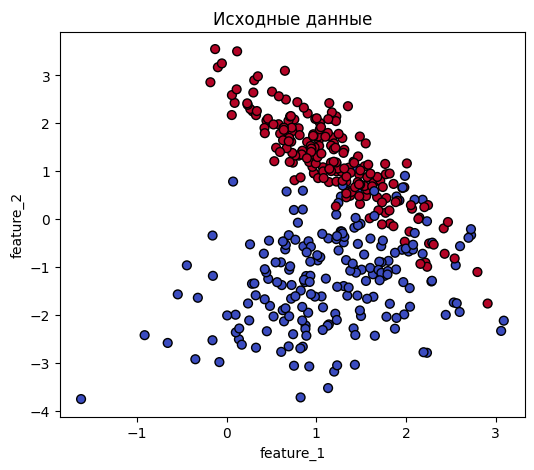

In [2]:
X, y = make_classification(
    n_samples=400, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.2, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
plt.title('Исходные данные')
plt.xlabel('feature_1'); plt.ylabel('feature_2')
plt.show()

## 2. Как дерево делает разбиения

Дерево на каждом шаге выбирает признак и порог, которые **максимально уменьшают неопределённость** в полученных подмножествах. Внизу видно, как граница режется по осям.

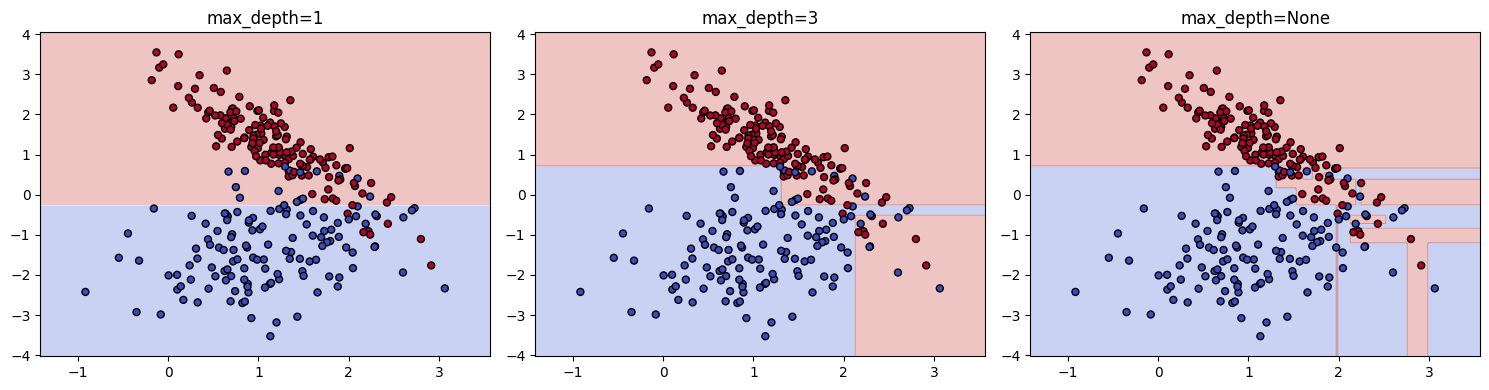

In [3]:
def plot_decision_boundary(model, X, y, ax, title=''):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=25)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, depth in zip(axes, [1, 3, None]):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    plot_decision_boundary(clf, X_train, y_train, ax, title=f'max_depth={depth}')
plt.tight_layout(); plt.show()

## 3. Критерии разбиения: Gini, Entropy, Log Loss

Все три критерия измеряют «нечистоту» узла. Для бинарной классификации с долей класса $p$:

- **Gini**: $1 - p^2 - (1-p)^2$
- **Entropy**: $-p \log_2 p - (1-p) \log_2 (1-p)$
- **Log Loss**: $-p \log p - (1-p) \log (1-p)$

Чем чище узел (p близко к 0 или 1), тем меньше значение.

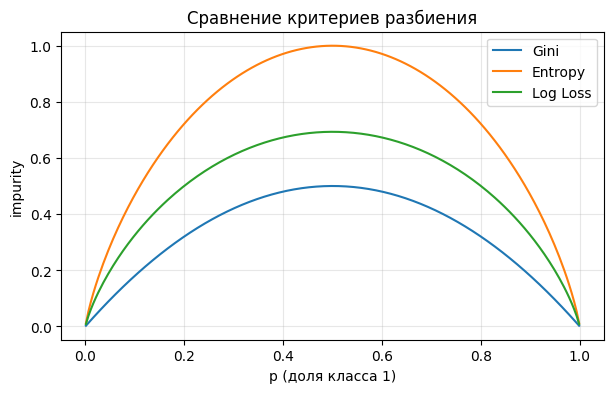

In [4]:
p = np.linspace(0.001, 0.999, 200)
gini    = 1 - p**2 - (1-p)**2
entropy = -p*np.log2(p) - (1-p)*np.log2(1-p)
logloss = -p*np.log(p) - (1-p)*np.log(1-p)

plt.figure(figsize=(7, 4))
plt.plot(p, gini, label='Gini')
plt.plot(p, entropy, label='Entropy')
plt.plot(p, logloss, label='Log Loss')
plt.xlabel('p (доля класса 1)'); plt.ylabel('impurity')
plt.title('Сравнение критериев разбиения')
plt.legend(); plt.grid(alpha=0.3); plt.show()

Сравнение моделей с разными критериями.

In [5]:
for crit in ['gini', 'entropy', 'log_loss']:
    clf = DecisionTreeClassifier(criterion=crit, max_depth=4, random_state=42).fit(X_train, y_train)
    print(f'{crit:>9} | accuracy: {clf.score(X_test, y_test):.3f}')

     gini | accuracy: 0.875
  entropy | accuracy: 0.883
 log_loss | accuracy: 0.883


## 4. Визуализация дерева

В каждом узле видно: признак и порог разбиения, значение критерия, число объектов и распределение по классам.

В **листьях** дерево хранит:
- предсказанный класс (мажоритарный),
- распределение объектов по классам — отсюда получаются **вероятности**.

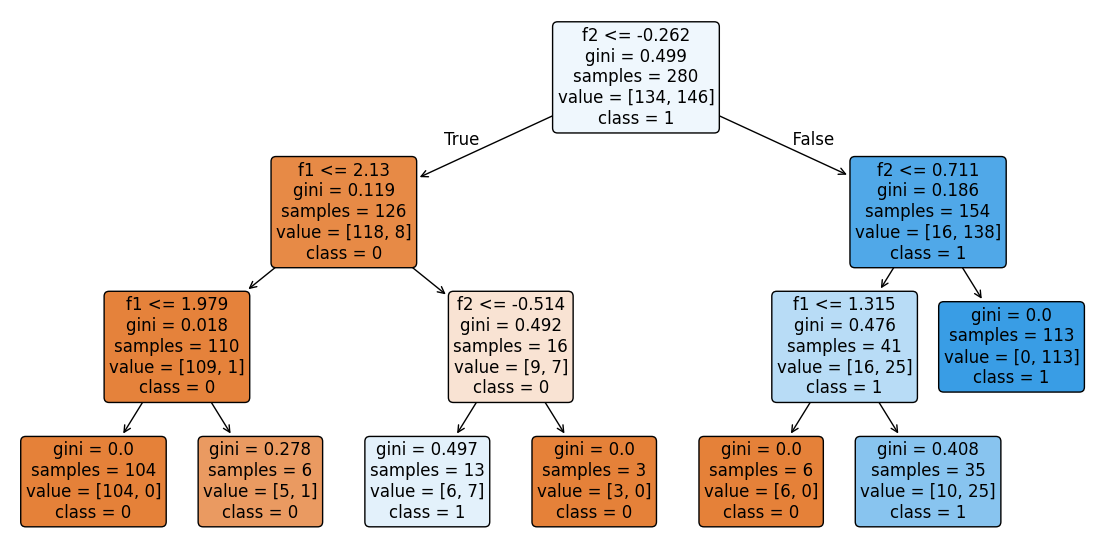

In [6]:
tree_small = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(tree_small, filled=True, feature_names=['f1', 'f2'], class_names=['0', '1'], rounded=True)
plt.show()

In [7]:
sample = X_test[:5]
print('predict       :', tree_small.predict(sample))
print('predict_proba :')
print(pd.DataFrame(tree_small.predict_proba(sample), columns=['P(class=0)', 'P(class=1)']).round(3))

predict       : [1 1 0 0 0]
predict_proba :
   P(class=0)  P(class=1)
0         0.0         1.0
1         0.0         1.0
2         1.0         0.0
3         1.0         0.0
4         1.0         0.0


## 5. Влияние `max_depth` (глубины) на переобучение

Чем глубже дерево, тем точнее оно повторяет обучающую выборку, но качество на тесте после некоторой глубины падает.

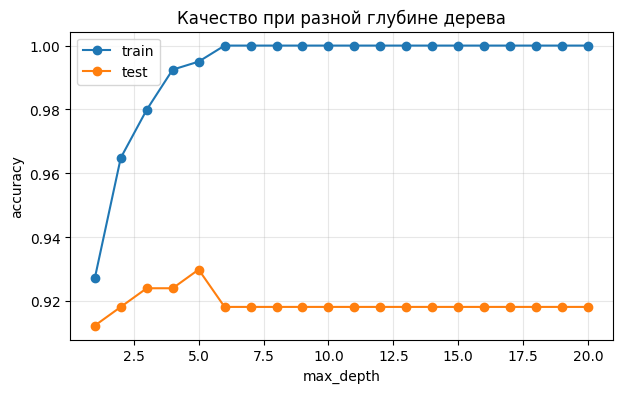

In [8]:
data = load_breast_cancer()
Xb, yb = data.data, data.target
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3, random_state=42, stratify=yb)

depths = range(1, 21)
train_acc, test_acc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(Xb_tr, yb_tr)
    train_acc.append(m.score(Xb_tr, yb_tr))
    test_acc.append(m.score(Xb_te, yb_te))

plt.figure(figsize=(7, 4))
plt.plot(depths, train_acc, marker='o', label='train')
plt.plot(depths, test_acc,  marker='o', label='test')
plt.xlabel('max_depth'); plt.ylabel('accuracy')
plt.title('Качество при разной глубине дерева')
plt.legend(); plt.grid(alpha=0.3); plt.show()

Видно классическую картину: train растёт до 1.0, а test выходит на плато и может слегка проседать — это и есть переобучение.

## 6. Метрики качества

Возьмём дерево с разумной глубиной и посчитаем основные метрики бинарной классификации.

In [9]:
model = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xb_tr, yb_tr)

y_pred  = model.predict(Xb_te)
y_proba = model.predict_proba(Xb_te)[:, 1]

metrics = {
    'Accuracy' : accuracy_score(yb_te, y_pred),
    'Precision': precision_score(yb_te, y_pred),
    'Recall'   : recall_score(yb_te, y_pred),
    'F1-score' : f1_score(yb_te, y_pred),
    'ROC-AUC'  : roc_auc_score(yb_te, y_proba),
}
pd.Series(metrics).round(3).to_frame('value')

,value
Accuracy,0.924
Precision,0.935
Recall,0.944
F1-score,0.940
ROC-AUC,0.925


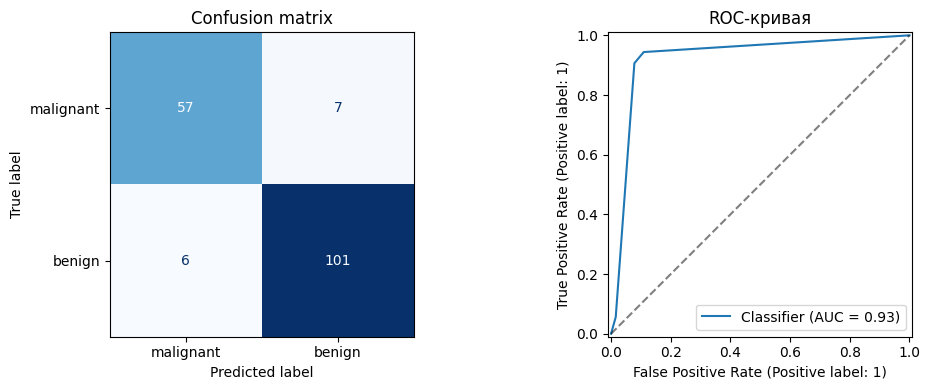

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(yb_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix')

RocCurveDisplay.from_predictions(yb_te, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC-кривая')

plt.tight_layout(); plt.show()

## 7. Feature importance

Дерево умеет оценивать, насколько каждый признак уменьшил суммарную нечистоту.

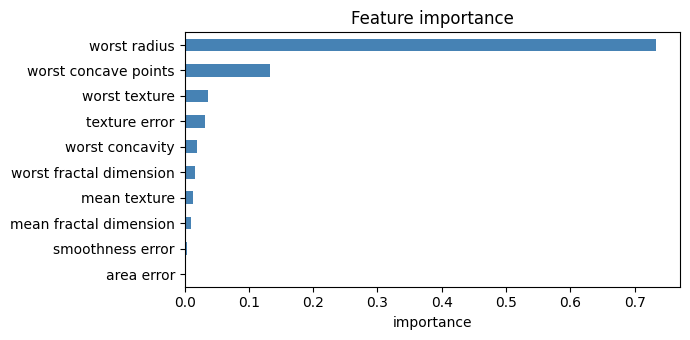

In [11]:
imp = pd.Series(model.feature_importances_, index=data.feature_names).sort_values(ascending=True)
imp = imp[imp > 0]

plt.figure(figsize=(7, max(3, len(imp)*0.35)))
imp.plot(kind='barh', color='steelblue')
plt.title('Feature importance')
plt.xlabel('importance')
plt.tight_layout(); plt.show()

#**Общий итог:**

- Дерево строит разбиения, минимизируя нечистоту узлов (Gini / Entropy / Log Loss).
- В листьях хранятся распределения классов.
- `max_depth` (глубина) — главный регулятор переобучения: слишком большая глубина ⇒ идеальный train и слабый test.
- Качество удобно оценивать набором метрик: Accuracy, Precision, Recall, F1, ROC-AUC, плюс confusion matrix и feature importance.